In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset

Now, let's load the `flipkard.csv` file into a pandas DataFrame and display the first few rows to understand its structure.

In [2]:
df = pd.read_csv('/content/flipkard.csv')
display(df.head())

,product_id,product_name,category,brand,seller,seller_city,price,discount_percent,final_price,rating,...,weight_g,warranty_months,color,size,return_policy_days,is_returnable,payment_modes,shipping_weight_g,product_score,seller_rating
0,FKP0000001,Adidas Ultra 664,Toys,Adidas,MegaStore,Hyderabad,35547.34,15,30215.24,1.9,...,3038.23,36,Green,XL,30,True,"COD,CARD",3483.592454,6.78,3.28
1,FKP0000002,LG Series 124,Fashion,LG,ValueKart,Mumbai,30693.79,10,27624.41,3.2,...,1921.82,0,Grey,One Size,7,True,"UPI,CARD",2091.473835,50.78,3.42
2,FKP0000003,Redmi Model 35,Beauty,Redmi,SmartDeals,Ahmedabad,51214.50,40,30728.70,4.4,...,1143.49,12,Black,M,0,False,"COD,UPI,CARD",1242.770494,4.24,4.23
3,FKP0000004,Sony Edition 769,Toys,Sony,UrbanRetails,Delhi,33168.49,30,23217.94,2.8,...,3644.81,24,Black,L,0,False,"CARD,Wallet",3891.222716,1.38,3.45
4,FKP0000005,Boat Prime 291,Home & Kitchen,Boat,RetailHub,Pune,14181.34,0,14181.34,3.7,...,310.33,0,Blue,NaN,30,True,"CARD,Wallet",386.061014,79.27,4.90


## Check for Missing Values

Next, let's check for any missing values in the dataset to understand its completeness.

In [3]:
print('Number of null values per column:')
display(df.isnull().sum())

Number of null values per column:


,0
product_id,0
product_name,0
category,0
brand,0
seller,0
seller_city,0
price,0
discount_percent,0
final_price,0
rating,0


## Check Unique Values

Finally, let's examine the number of unique values for each column to get an idea of their cardinality.

In [4]:
print('Number of unique values per column:')
display(df.nunique())

Number of unique values per column:


,0
product_id,80000
product_name,48801
category,8
brand,15
seller,8
seller_city,8
price,79511
discount_percent,8
final_price,79378
rating,41


## Handle Missing Values

Since the `size` column has missing values, we'll remove the rows containing these nulls to ensure data completeness for further analysis. We'll then verify that no null values remain.

In [5]:
# Remove rows with null values in the 'size' column
df_cleaned = df.dropna(subset=['size'])

print(f"Original number of rows: {len(df)}")
print(f"Number of rows after dropping nulls: {len(df_cleaned)}")

# Verify that there are no more null values in the 'size' column
print('\nNumber of null values after cleaning:')
display(df_cleaned.isnull().sum())

Original number of rows: 80000
Number of rows after dropping nulls: 66516

Number of null values after cleaning:


,0
product_id,0
product_name,0
category,0
brand,0
seller,0
seller_city,0
price,0
discount_percent,0
final_price,0
rating,0


## Remove Irrelevant Columns

As requested, we will now remove the identified irrelevant columns (`product_name`, `seller`, `seller_city`, `shipping_weight_g`) from the `df_cleaned` DataFrame. We will keep `product_id`.

In [9]:
columns_to_drop_now = [
    'color', 'size', 'is_returnable', 'weight_g', 'delivery_days',
    'payment_modes', 'stock_available', 'product_score', 'seller_rating',
    'warranty_months', 'return_policy_days'
]

df_cleaned = df_cleaned.drop(columns=columns_to_drop_now, errors='ignore')

print(f"Columns remaining in df_cleaned: {df_cleaned.columns.tolist()}")
display(df_cleaned.head())

Columns remaining in df_cleaned: ['product_id', 'category', 'brand', 'price', 'discount_percent', 'final_price', 'rating', 'review_count', 'units_sold', 'listing_date']


,product_id,category,brand,price,discount_percent,final_price,rating,review_count,units_sold,listing_date
0,FKP0000001,Toys,Adidas,35547.34,15,30215.24,1.9,26975,66,2022-04-12
1,FKP0000002,Fashion,LG,30693.79,10,27624.41,3.2,45848,2703,2023-05-14
2,FKP0000003,Beauty,Redmi,51214.50,40,30728.70,4.4,5138,2394,2022-09-13
3,FKP0000004,Toys,Sony,33168.49,30,23217.94,2.8,2000,1732,2019-08-05
7,FKP0000008,Beauty,Philips,9330.32,5,8863.80,3.6,9135,4607,2020-04-08


In [10]:
df_cleaned = df_cleaned.rename(columns={'review_count': 'rating_count'})

print(f"Updated columns in df_cleaned: {df_cleaned.columns.tolist()}")
display(df_cleaned.head())

Updated columns in df_cleaned: ['product_id', 'category', 'brand', 'price', 'discount_percent', 'final_price', 'rating', 'rating_count', 'units_sold', 'listing_date']


,product_id,category,brand,price,discount_percent,final_price,rating,rating_count,units_sold,listing_date
0,FKP0000001,Toys,Adidas,35547.34,15,30215.24,1.9,26975,66,2022-04-12
1,FKP0000002,Fashion,LG,30693.79,10,27624.41,3.2,45848,2703,2023-05-14
2,FKP0000003,Beauty,Redmi,51214.50,40,30728.70,4.4,5138,2394,2022-09-13
3,FKP0000004,Toys,Sony,33168.49,30,23217.94,2.8,2000,1732,2019-08-05
7,FKP0000008,Beauty,Philips,9330.32,5,8863.80,3.6,9135,4607,2020-04-08


### Data Preparation for Date-based Analysis

To enable time-series analysis or any date-related operations, we'll convert the `listing_date` column to a datetime object.

In [18]:
df_cleaned['listing_date'] = pd.to_datetime(df_cleaned['listing_date'])
display(df_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
Index: 66516 entries, 0 to 79999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   product_id        66516 non-null  object        
 1   category          66516 non-null  object        
 2   brand             66516 non-null  object        
 3   price             66516 non-null  float64       
 4   discount_percent  66516 non-null  int64         
 5   final_price       66516 non-null  float64       
 6   rating            66516 non-null  float64       
 7   rating_count      66516 non-null  int64         
 8   units_sold        66516 non-null  int64         
 9   listing_date      66516 non-null  datetime64[ns]
 10  discount_tier     66516 non-null  category      
 11  rating_band       66516 non-null  category      
 12  absolute_savings  66516 non-null  float64       
dtypes: category(2), datetime64[ns](1), float64(4), int64(3), object(3)
memory usage: 

None

### Visualization 1: Distribution of Final Prices

Let's visualize the distribution of `final_price` to understand the pricing patterns and common price ranges of products in the dataset.

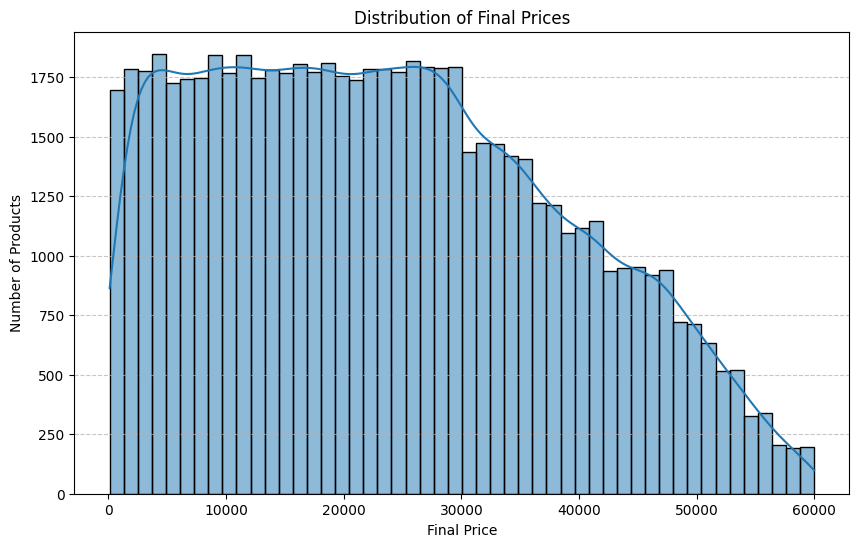

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['final_price'], bins=50, kde=True)
plt.title('Distribution of Final Prices')
plt.xlabel('Final Price')
plt.ylabel('Number of Products')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Visualization 2: Top 10 Brands by Units Sold

This bar chart will highlight the brands with the highest total `units_sold`, giving an insight into market leaders.

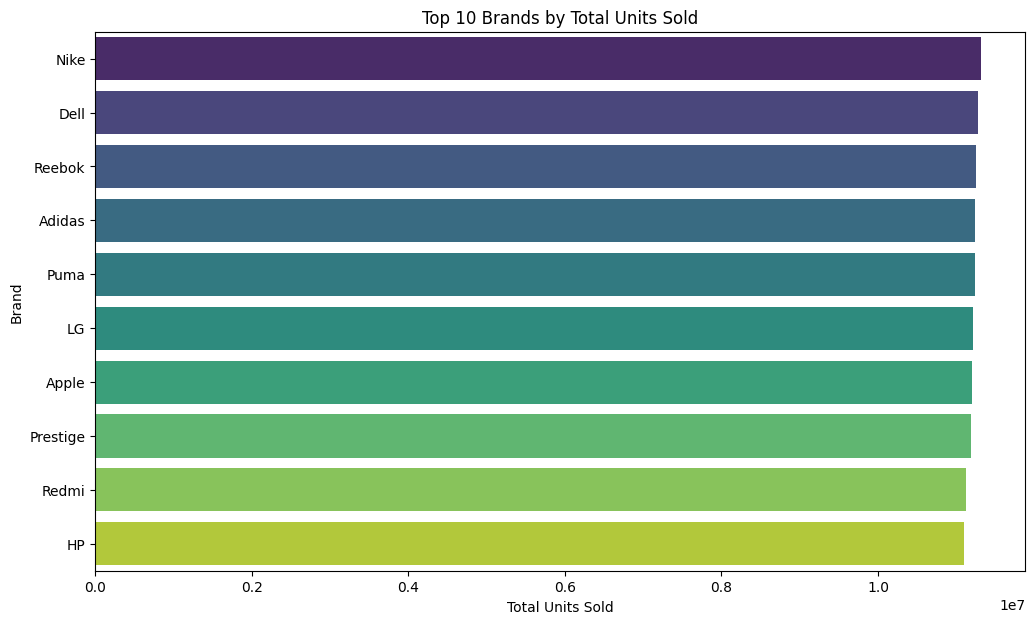

In [22]:
top_brands = df_cleaned.groupby('brand')['units_sold'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='units_sold', y='brand', data=top_brands, palette='viridis', hue='brand', legend=False)
plt.title('Top 10 Brands by Total Units Sold')
plt.xlabel('Total Units Sold')
plt.ylabel('Brand')
plt.show()

### Visualization 3: Average Rating per Category

Let's examine the average customer `rating` for each `category` to understand which product categories generally receive higher satisfaction.

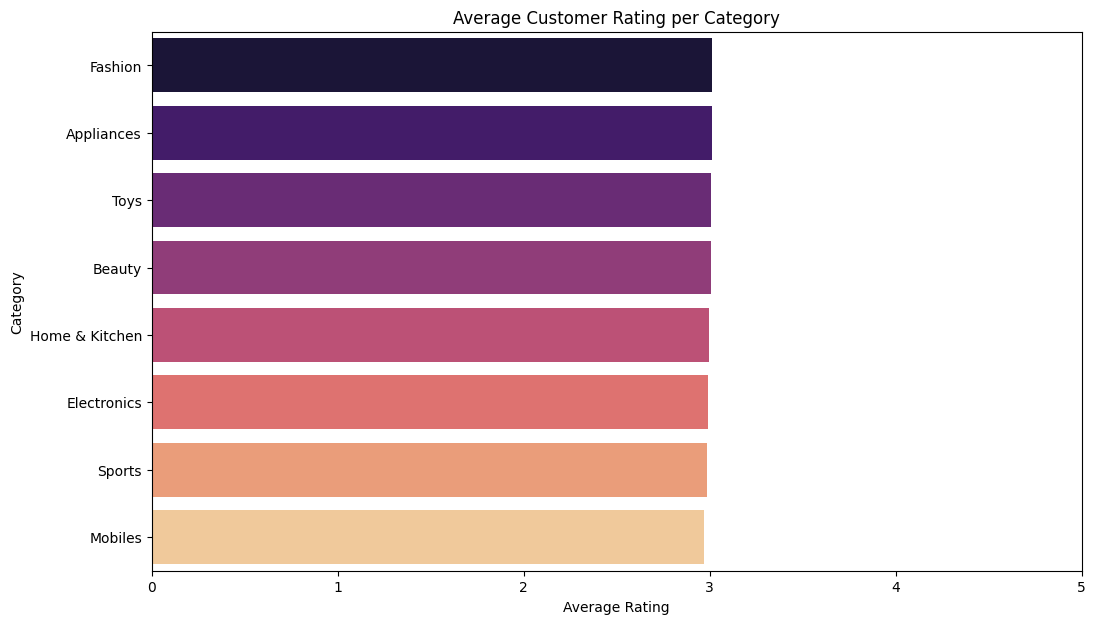

In [23]:
avg_rating_per_category = df_cleaned.groupby('category')['rating'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='rating', y='category', data=avg_rating_per_category, palette='magma', hue='category', legend=False)
plt.title('Average Customer Rating per Category')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.xlim(0, 5) # Assuming ratings are on a 1-5 scale
plt.show()

### Visualization 4: Total Units Sold Over Time

This line chart will track the total `units_sold` aggregated by month and year, providing insights into sales velocity and potential seasonality.

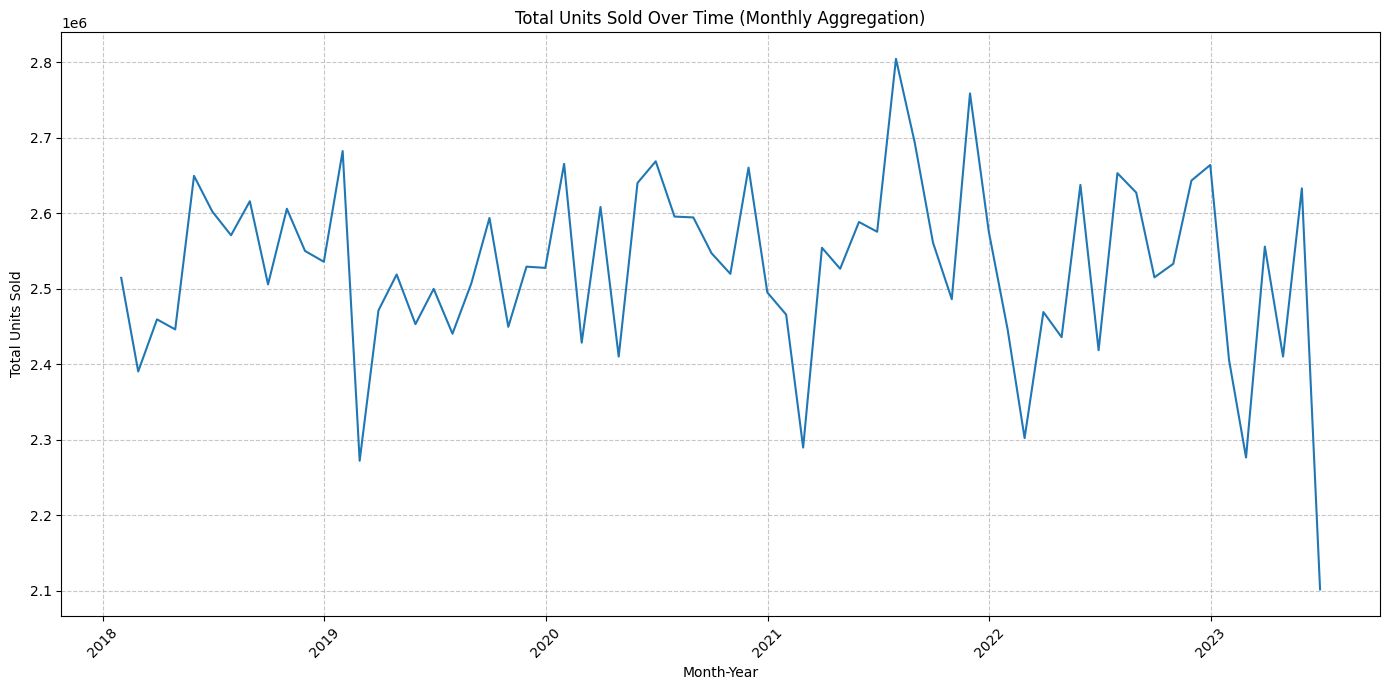

In [29]:
# Group by month and year of listing_date and sum units_sold
sales_over_time = df_cleaned.set_index('listing_date').resample('ME')['units_sold'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='listing_date', y='units_sold', data=sales_over_time)
plt.title('Total Units Sold Over Time (Monthly Aggregation)')
plt.xlabel('Month-Year')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualization 5: Total Units Sold and Total Revenue by Category

This grouped bar chart will show both `units_sold` and calculated `total_revenue` for each product category, helping identify top-performing categories.

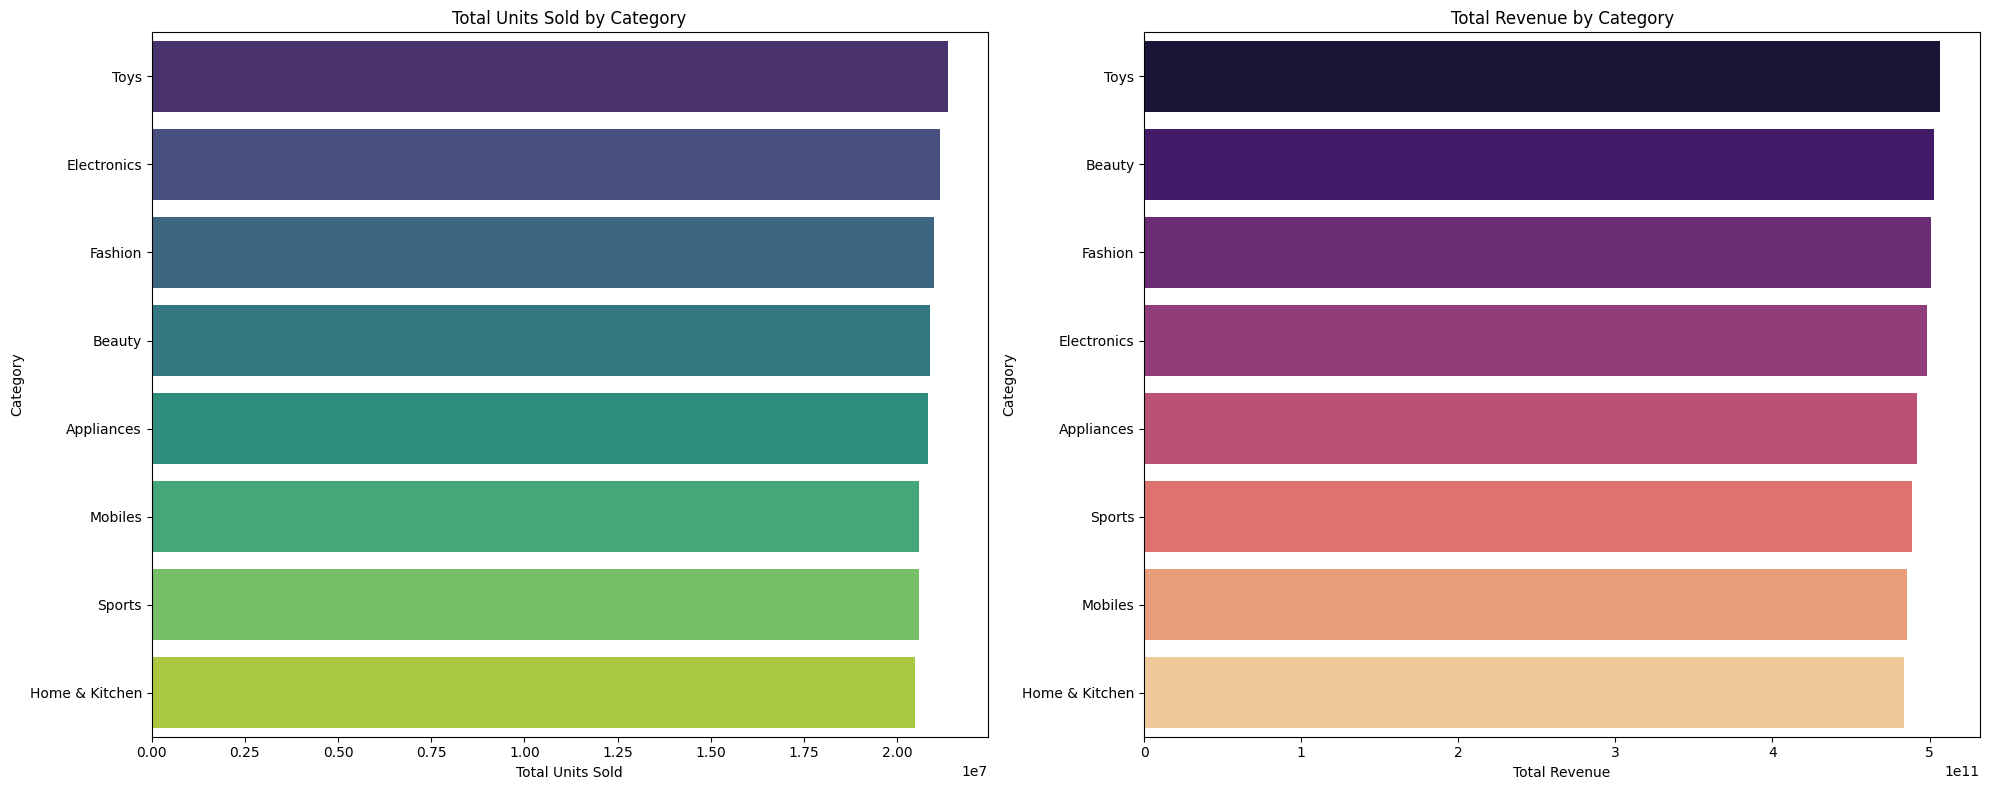

In [25]:
# Calculate Total Revenue
df_cleaned['total_revenue'] = df_cleaned['final_price'] * df_cleaned['units_sold']

# Aggregate by category
category_performance = df_cleaned.groupby('category').agg(
    total_units_sold=('units_sold', 'sum'),
    total_revenue=('total_revenue', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(x='total_units_sold', y='category', data=category_performance.sort_values('total_units_sold', ascending=False), palette='viridis', hue='category', legend=False, ax=axes[0])
axes[0].set_title('Total Units Sold by Category')
axes[0].set_xlabel('Total Units Sold')
axes[0].set_ylabel('Category')

sns.barplot(x='total_revenue', y='category', data=category_performance.sort_values('total_revenue', ascending=False), palette='magma', hue='category', legend=False, ax=axes[1])
axes[1].set_title('Total Revenue by Category')
axes[1].set_xlabel('Total Revenue')
axes[1].set_ylabel('Category')

plt.tight_layout()
plt.show()

### Visualization 7: Price Distribution Across Top 10 Brands (Box Plot)

This box plot illustrates the `final_price` distribution for the top 10 brands, revealing their pricing strategies and any price outliers.

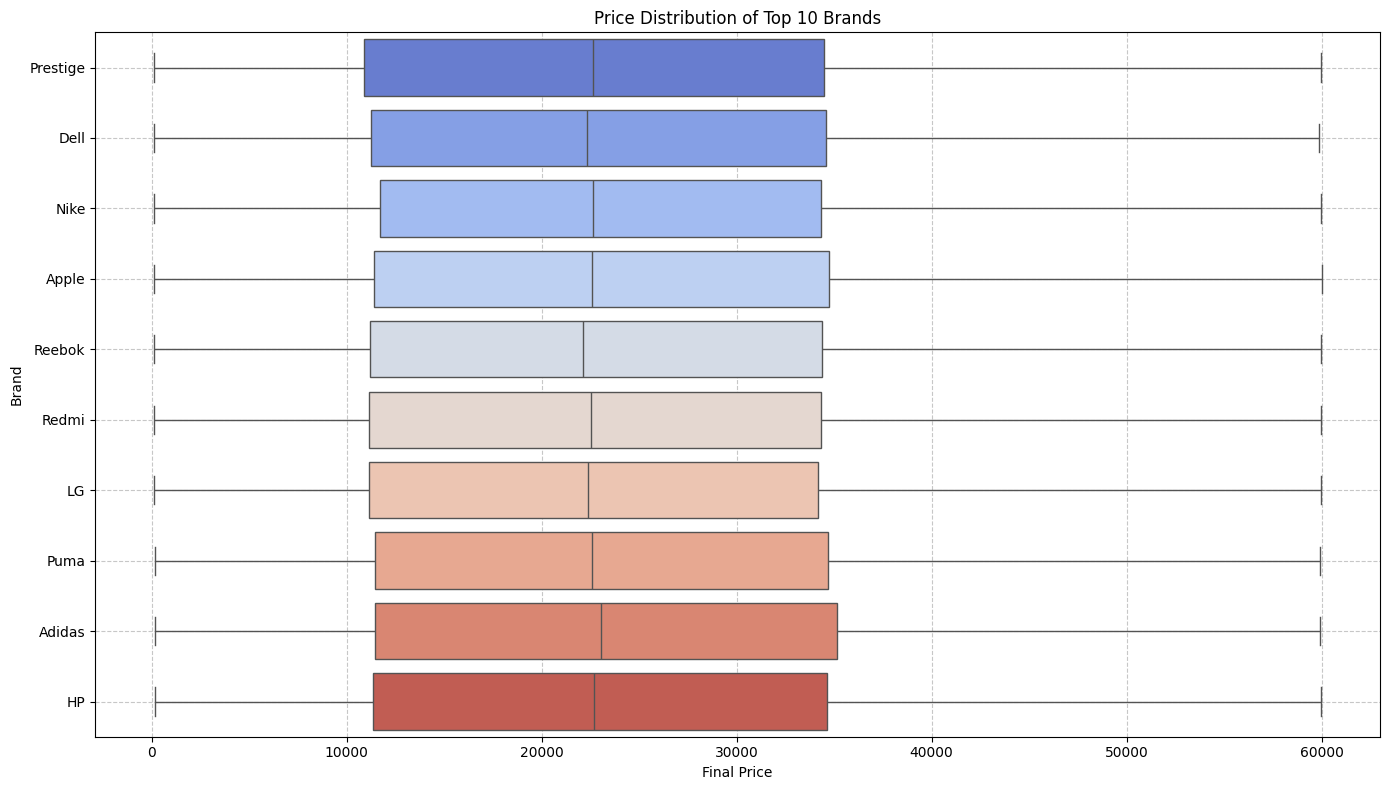

In [27]:
# Use the previously identified top_brands list
brands_for_boxplot = top_brands['brand'].tolist()
filtered_df_brands = df_cleaned[df_cleaned['brand'].isin(brands_for_boxplot)]

plt.figure(figsize=(14, 8))
sns.boxplot(x='final_price', y='brand', data=filtered_df_brands.sort_values('final_price'), palette='coolwarm', hue='brand', legend=False)
plt.title('Price Distribution of Top 10 Brands')
plt.xlabel('Final Price')
plt.ylabel('Brand')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualization 8: Correlation Heatmap for Rating and Sales Metrics

This heatmap displays the correlation coefficients between `rating`, `rating_count`, `units_sold`, `discount_percent`, and `final_price` to understand their relationships.

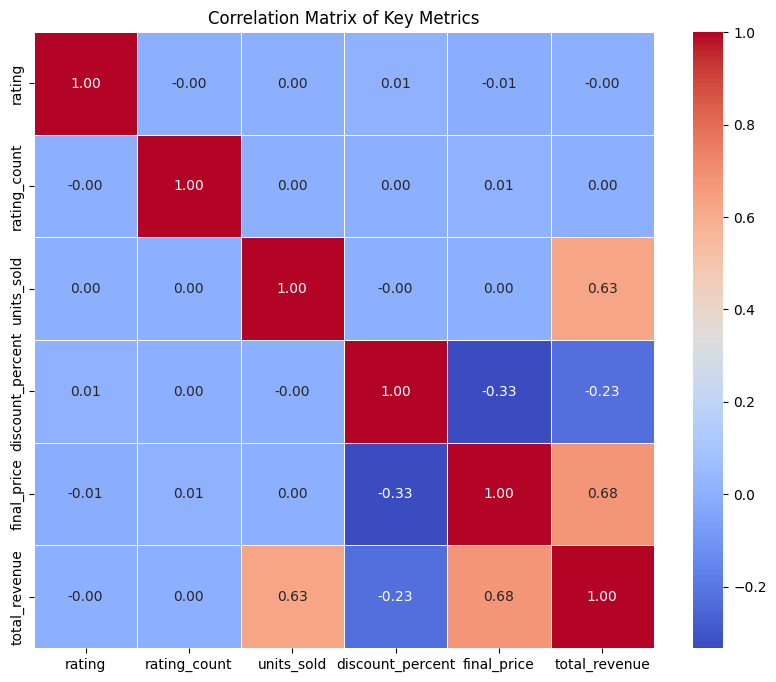

In [28]:
correlation_cols = ['rating', 'rating_count', 'units_sold', 'discount_percent', 'final_price', 'total_revenue']
correlation_matrix = df_cleaned[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Key Metrics')
plt.show()

In [37]:
display(df_cleaned.head())

,product_id,category,brand,price,discount_percent,final_price,rating,rating_count,units_sold,listing_date
0,FKP0000001,Toys,Adidas,35547.34,15,30215.24,1.9,26975,66,2022-04-12
1,FKP0000002,Fashion,LG,30693.79,10,27624.41,3.2,45848,2703,2023-05-14
2,FKP0000003,Beauty,Redmi,51214.50,40,30728.70,4.4,5138,2394,2022-09-13
3,FKP0000004,Toys,Sony,33168.49,30,23217.94,2.8,2000,1732,2019-08-05
7,FKP0000008,Beauty,Philips,9330.32,5,8863.80,3.6,9135,4607,2020-04-08


In [38]:
columns_to_remove = ['discount_tier', 'rating_band', 'absolute_savings', 'total_revenue']
df_cleaned = df_cleaned.drop(columns=columns_to_remove, errors='ignore')
display(df_cleaned.head())

,product_id,category,brand,price,discount_percent,final_price,rating,rating_count,units_sold,listing_date
0,FKP0000001,Toys,Adidas,35547.34,15,30215.24,1.9,26975,66,2022-04-12
1,FKP0000002,Fashion,LG,30693.79,10,27624.41,3.2,45848,2703,2023-05-14
2,FKP0000003,Beauty,Redmi,51214.50,40,30728.70,4.4,5138,2394,2022-09-13
3,FKP0000004,Toys,Sony,33168.49,30,23217.94,2.8,2000,1732,2019-08-05
7,FKP0000008,Beauty,Philips,9330.32,5,8863.80,3.6,9135,4607,2020-04-08


In [39]:
df_cleaned.to_csv('flipkart-cleaned.csv', index=False)
print('DataFrame exported successfully to flipkart-cleaned.csv')

DataFrame exported successfully to flipkart-cleaned.csv
